In [ ]:
import os
import pandas as pd
import numpy as np
import datetime
from scipy import sparse
from scipy.sparse import coo_matrix, diags
import matplotlib.pyplot as plt
from collections import deque

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/Math168/fraud_detection/"
print(os.listdir(path))

['fraudTrain.csv', 'fraudTest.csv', 'tx_birank_priors.csv']


In [ ]:
fraudTest = pd.read_csv(path + "fraudTest.csv", index_col=0)
fraudTrain = pd.read_csv(path + "fraudTrain.csv", index_col=0)
fraudTrain

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,Manderson,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0


In [ ]:
len(fraudTest)

555719

In [ ]:
fraudTrain["trans_date_trans_time"] = pd.to_datetime(fraudTrain["trans_date_trans_time"], errors="coerce", cache=True)
fraudTest["trans_date_trans_time"] = pd.to_datetime(fraudTest["trans_date_trans_time"], errors="coerce", cache=True)

In [ ]:
test_start = fraudTest["trans_date_trans_time"].min()
test_end   = test_start + pd.DateOffset(months=1)

fraudTest_1m = fraudTest[
    (fraudTest['trans_date_trans_time'] >= test_start) &
    (fraudTest['trans_date_trans_time'] < test_end)
].copy()

In [ ]:
fraudTrain = fraudTrain.assign(_split="train")
fraudTest_1m = fraudTest_1m.assign(_split="test_1m")


In [ ]:
fraudAll = pd.concat([fraudTrain, fraudTest_1m], ignore_index=True)
fraudAll["row_id_combined"] = np.arange(len(fraudAll), dtype=np.int64)

In [ ]:
fraudAll["event_date"] = fraudAll["trans_date_trans_time"].dt.floor("D")

In [ ]:
fraudAll["trans_num"].isna().sum(), fraudAll["trans_num"].duplicated().sum()

(np.int64(0), np.int64(0))

In [ ]:
fraudAll

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,_split,row_id_combined,event_date
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,train,0,2019-01-01
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,train,1,2019-01-01
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,train,2,2019-01-01
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,train,3,2019-01-01
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,train,4,2019-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384315,2020-07-21 12:13:27,6011366578560244,"fraud_Huel, Hammes and Witting",grocery_pos,102.10,Adam,Stark,M,0912 Mark Fields Apt. 080,Mc Veytown,...,Nutritional therapist,1997-07-01,28dbfcfd6288b406e125154d26a8048b,1374408807,41.103110,-77.601875,0,test_1m,1384315,2020-07-21
1384316,2020-07-21 12:13:30,2264937662466770,fraud_Labadie LLC,personal_care,7.95,Juan,Sherman,M,5939 Garcia Forges Suite 297,San Antonio,...,Land,1995-10-17,a057b7eecf1683d1109afd59d6478d6a,1374408810,29.993934,-98.163099,0,test_1m,1384316,2020-07-21
1384317,2020-07-21 12:13:32,30082025922891,fraud_Ernser-Feest,home,123.11,Kathleen,Thompson,F,199 Patterson Fords Apt. 132,Naples,...,"Pilot, airline",1934-06-23,ba8f31627906ee914d3150b3557ebe03,1374408812,25.973459,-81.848113,0,test_1m,1384317,2020-07-21
1384318,2020-07-21 12:13:36,30235438713303,"fraud_Kerluke, Considine and Macejkovic",misc_net,811.45,James,Baldwin,M,3603 Mitchell Court,Winfield,...,Exhibition designer,1980-03-24,014019287afe680e698414b3ca38dc09,1374408816,37.583384,-82.006009,0,test_1m,1384318,2020-07-21


### EDA

Edge table shape: (489094, 5)
        cc_num                          merchant  txn_count  amt_sum  \
0  60416207185               fraud_Abbott-Rogahn          3    69.83   
1  60416207185              fraud_Abbott-Steuber          4   159.44   
2  60416207185          fraud_Abernathy and Sons          3    55.09   
3  60416207185                 fraud_Abshire PLC          2   156.15   
4  60416207185  fraud_Adams, Kovacek and Kuhlman          2   155.39   

   log_amt_sum  
0     8.511683  
1    13.848601  
2     7.516354  
3     8.673828  
4     8.730080  

[1] Edge-weight summary
                count        mean         std       min         50%  \
txn_count    489094.0    2.830376    1.978924  1.000000    2.000000   
amt_sum      489094.0  198.966081  319.536366  1.000000  114.260000   
log_amt_sum  489094.0   10.000548    7.932362  0.693147    7.976726   

                    90%         95%          99%         max  
txn_count      6.000000    7.000000     9.000000     25.0000  

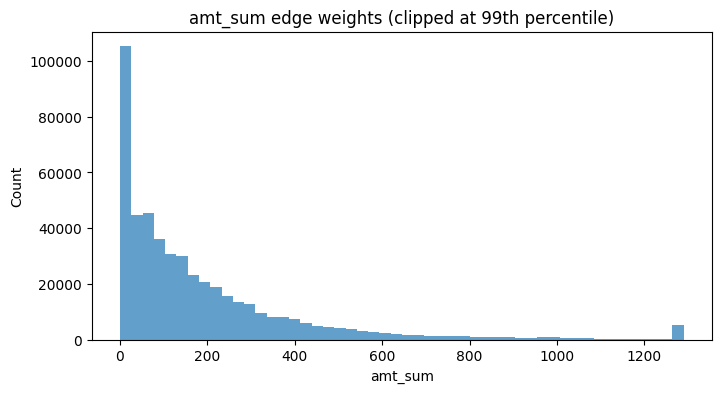

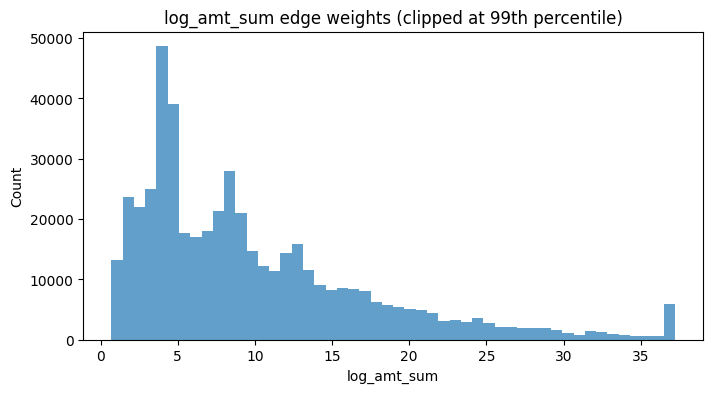


[2] Concentration test (share of total weight captured by top edges)
   weight_type  top_1pct_share  top_5pct_share
0    txn_count        0.038607        0.147877
1      amt_sum        0.104251        0.281058
2  log_amt_sum        0.044255        0.164990

[3] Rank correlation (Spearman) among merchant strength schemes
             rank_count  rank_amt  rank_logamt
rank_count     1.000000  0.824636     0.930018
rank_amt       0.824636  1.000000     0.702360
rank_logamt    0.930018  0.702360     1.000000

Top 15 merchants by raw amount strength
                               merchant  strength_amt  strength_logamt  \
316                   fraud_Kilback LLC     416505.53     19451.205141   
146                     fraud_Doyle Ltd     320177.69     12720.138324   
217             fraud_Hackett-Lueilwitz     320041.20     12834.693137   
572    fraud_Schumm, Bauch and Ondricka     319947.31     12630.220736   
73                    fraud_Bradtke PLC     318539.58     12585.403849   
494 

In [ ]:
# -----------------------------------------
# 0) Build edge table (card-merchant edges)
# -----------------------------------------
dfw = fraudAll[['cc_num', 'merchant', 'amt']].copy()
dfw['amt'] = pd.to_numeric(dfw['amt'], errors='coerce').clip(lower=0)
dfw = dfw.dropna(subset=['cc_num', 'merchant', 'amt']).copy()
dfw['log_amt'] = np.log1p(dfw['amt'])

edge_df = dfw.groupby(['cc_num', 'merchant'], as_index=False).agg(
    txn_count=('amt', 'size'),
    amt_sum=('amt', 'sum'),
    log_amt_sum=('log_amt', 'sum')
)

print("Edge table shape:", edge_df.shape)
print(edge_df.head())

# =========================================
# 1) Small EDA #1: Distribution summary
# =========================================
summary = edge_df[['txn_count', 'amt_sum', 'log_amt_sum']].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]
).T
print("\n[1] Edge-weight summary")
print(summary)

# Quick hist comparison (clipped for readability)
plt.figure(figsize=(8,4))
plt.hist(edge_df['amt_sum'].clip(upper=edge_df['amt_sum'].quantile(0.99)), bins=50, alpha=0.7)
plt.title("amt_sum edge weights (clipped at 99th percentile)")
plt.xlabel("amt_sum")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(edge_df['log_amt_sum'].clip(upper=edge_df['log_amt_sum'].quantile(0.99)), bins=50, alpha=0.7)
plt.title("log_amt_sum edge weights (clipped at 99th percentile)")
plt.xlabel("log_amt_sum")
plt.ylabel("Count")
plt.show()

# =========================================
# 2) Small EDA #2: Concentration test
#    (top 1% / 5% edges capture how much?)
# =========================================
def top_weight_share(values, top_frac):
    x = np.sort(np.asarray(values, dtype=float))[::-1]
    k = max(1, int(np.ceil(len(x) * top_frac)))
    return x[:k].sum() / x.sum()

conc = pd.DataFrame({
    'weight_type': ['txn_count', 'amt_sum', 'log_amt_sum'],
    'top_1pct_share': [
        top_weight_share(edge_df['txn_count'], 0.01),
        top_weight_share(edge_df['amt_sum'], 0.01),
        top_weight_share(edge_df['log_amt_sum'], 0.01),
    ],
    'top_5pct_share': [
        top_weight_share(edge_df['txn_count'], 0.05),
        top_weight_share(edge_df['amt_sum'], 0.05),
        top_weight_share(edge_df['log_amt_sum'], 0.05),
    ]
})

print("\n[2] Concentration test (share of total weight captured by top edges)")
print(conc)

# =========================================
# 3) Small EDA #3: Top-merchant ranking comparison
# =========================================
merchant_strength = edge_df.groupby('merchant', as_index=False).agg(
    strength_count=('txn_count', 'sum'),
    strength_amt=('amt_sum', 'sum'),
    strength_logamt=('log_amt_sum', 'sum'),
    degree_cards=('cc_num', 'nunique')
)

# Rank each merchant by different strength definitions
merchant_strength['rank_amt'] = merchant_strength['strength_amt'].rank(ascending=False, method='average')
merchant_strength['rank_logamt'] = merchant_strength['strength_logamt'].rank(ascending=False, method='average')
merchant_strength['rank_count'] = merchant_strength['strength_count'].rank(ascending=False, method='average')

print("\n[3] Rank correlation (Spearman) among merchant strength schemes")
print(merchant_strength[['rank_count', 'rank_amt', 'rank_logamt']].corr(method='spearman'))

print("\nTop 15 merchants by raw amount strength")
print(
    merchant_strength.sort_values('strength_amt', ascending=False)[
        ['merchant', 'strength_amt', 'strength_logamt', 'strength_count', 'degree_cards']
    ].head(15)
)

print("\nTop 15 merchants by log-amount strength")
print(
    merchant_strength.sort_values('strength_logamt', ascending=False)[
        ['merchant', 'strength_amt', 'strength_logamt', 'strength_count', 'degree_cards']
    ].head(15)
)

### Bipartite Graph

In [ ]:
raw = fraudAll.copy()

In [ ]:
raw['trans_date_trans_time'] = pd.to_datetime(raw['trans_date_trans_time'], errors='coerce')
raw['event_date'] = raw['trans_date_trans_time'].dt.floor('D')
raw['log_amt'] = np.log1p(fraudAll['amt'].clip(lower=0).values)

In [ ]:
"""print("Transactions after cleaning:", len(raw))
print("Date range:", raw['event_date'].min(), "to", raw['event_date'].max())"""

'print("Transactions after cleaning:", len(raw))\nprint("Date range:", raw[\'event_date\'].min(), "to", raw[\'event_date\'].max())'

In [ ]:
# 1) daily edge contributions
daily_edge_tables = {}
for day, g in raw.groupby('event_date', sort=True):
    edge_day = g.groupby(['cc_num', 'merchant'], as_index=False).agg(
        txn_count=('amt', 'size'),
        amt_sum=('amt', 'sum'),
        log_amt_sum=('log_amt', 'sum')
    )
    daily_edge_tables[day] = edge_day

In [ ]:
"""print("Number of daily edge tables:", len(daily_edge_tables))

example_day = sorted(daily_edge_tables.keys())[0]
print("Example day:", example_day)
print(daily_edge_tables[example_day].head())"""

'print("Number of daily edge tables:", len(daily_edge_tables))\n\nexample_day = sorted(daily_edge_tables.keys())[0]\nprint("Example day:", example_day)\nprint(daily_edge_tables[example_day].head())'

In [ ]:
def update_edge_store_add(edge_store, edge_df):
    for row in edge_df.itertuples(index=False):
        key = (row.cc_num, row.merchant)
        if key in edge_store:
            edge_store[key][0] += int(row.txn_count)
            edge_store[key][1] += float(row.amt_sum)
            edge_store[key][2] += float(row.log_amt_sum)
        else:
            edge_store[key] = [int(row.txn_count), float(row.amt_sum), float(row.log_amt_sum)]

def update_edge_store_subtract(edge_store, edge_df, tol=1e-12):
    for row in edge_df.itertuples(index=False):
        key = (row.cc_num, row.merchant)
        if key not in edge_store:
            continue

        edge_store[key][0] -= int(row.txn_count)
        edge_store[key][1] -= float(row.amt_sum)
        edge_store[key][2] -= float(row.log_amt_sum)

        c, a, l = edge_store[key]
        if (c <= 0) and (abs(a) <= tol) and (abs(l) <= tol):
            del edge_store[key]

def edge_store_to_df(edge_store):
    if not edge_store:
        return pd.DataFrame(columns=['cc_num', 'merchant', 'txn_count', 'amt_sum', 'log_amt_sum'])

    rows = []
    for (cc, m), (cnt, amt_sum, log_amt_sum) in edge_store.items():
        rows.append((cc, m, cnt, amt_sum, log_amt_sum))

    return pd.DataFrame(rows, columns=['cc_num', 'merchant', 'txn_count', 'amt_sum', 'log_amt_sum'])

In [ ]:
all_days = raw['event_date'].sort_values().unique()

rolling_edge_tables = {}
edge_store = {}
window_days = deque()

WINDOW_DAYS = 90

In [ ]:
for target_day in all_days:
    # remove days older than target day
    min_day_in_window = target_day - pd.Timedelta(days=WINDOW_DAYS)

    while window_days and (window_days[0] < min_day_in_window):
        old_day = window_days.popleft()
        update_edge_store_subtract(edge_store, daily_edge_tables[old_day])

    rolling_edge_tables[target_day] = edge_store_to_df(edge_store)

    ## add current day edges
    update_edge_store_add(edge_store, daily_edge_tables[target_day])
    window_days.append(target_day)

In [ ]:
print("Built rolling edge tables for", len(rolling_edge_tables), "target days")
sample_target_day = all_days[min(35, len(all_days)-1)]  # choose a day after warm-up if possible
print("Sample target day:", sample_target_day)
print("Rolling 30d edge table shape:", rolling_edge_tables[sample_target_day].shape)
print(rolling_edge_tables[sample_target_day])

Built rolling edge tables for 567 target days
Sample target day: 2019-02-05 00:00:00
Rolling 30d edge table shape: (55948, 5)
                    cc_num                           merchant  txn_count  \
0              60416207185  fraud_Jones, Sawayn and Romaguera          1   
1              60423098130              fraud_Kuphal-Predovic          1   
2              60423098130              fraud_Shanahan-Lehner          1   
3              60427851591                    fraud_Kiehn Inc          2   
4              60490596305                    fraud_Beier LLC          1   
...                    ...                                ...        ...   
55943  4989847570577635369                    fraud_Lesch Ltd          1   
55944  4992346398065154184              fraud_Connelly-Carter          1   
55945  4992346398065154184  fraud_Eichmann, Hayes and Treutel          1   
55946  4992346398065154184  fraud_Schoen, Kuphal and Nitzsche          1   
55947  4992346398065154184   fraud_Zem

In [ ]:
sample = rolling_edge_tables[pd.Timestamp('2019-03-07')]

print(sample[['txn_count','amt_sum','log_amt_sum']].describe(percentiles=[.5,.9,.95,.99]).T)

print("Any negative counts?", (sample['txn_count'] < 0).any())
print("Any negative amt_sum?", (sample['amt_sum'] < 0).any())
print("Any negative log_amt_sum?", (sample['log_amt_sum'] < 0).any())

print("Rows with txn_count > 1:", (sample['txn_count'] > 1).sum())
print("Share txn_count = 1:", (sample['txn_count'] == 1).mean())

                count       mean         std       min        50%         90%  \
txn_count    102206.0   1.138162    0.389430  1.000000   1.000000    2.000000   
amt_sum      102206.0  81.646484  164.854556  1.000000  51.900000  163.785000   
log_amt_sum  102206.0   4.033672    2.028805  0.693147   4.021057    6.283826   

                    95%         99%           max  
txn_count      2.000000    3.000000      6.000000  
amt_sum      235.550000  695.196500  12788.070000  
log_amt_sum    8.263242   10.725653     26.655058  
Any negative counts? False
Any negative amt_sum? False
Any negative log_amt_sum? False
Rows with txn_count > 1: 12624
Share txn_count = 1: 0.8764847464923782


### BiRank Analysis

In [ ]:
def build_W_from_edge_table(edge_df, weight_col='log_amt_sum'):
    """
    edge_df columns needed: cc_num, merchant, {weight_col}
    Returns W (cards x merchants), node lists, and weighted degrees.
    """
    if edge_df.empty:
        return None, [], [], None, None

    # Node mappings
    card_nodes = edge_df['cc_num'].drop_duplicates().tolist()
    merchant_nodes = edge_df['merchant'].drop_duplicates().tolist()

    card_to_idx = {c: i for i, c in enumerate(card_nodes)}
    merchant_to_idx = {m: j for j, m in enumerate(merchant_nodes)}

    rows = edge_df['cc_num'].map(card_to_idx).to_numpy()
    cols = edge_df['merchant'].map(merchant_to_idx).to_numpy()
    vals = edge_df[weight_col].to_numpy(dtype=float)

    W = coo_matrix(
        (vals, (rows, cols)),
        shape=(len(card_nodes), len(merchant_nodes))
    ).tocsr()

    du = np.asarray(W.sum(axis=1)).ravel()  # card weighted degrees
    dp = np.asarray(W.sum(axis=0)).ravel()  # merchant weighted degrees

    return W, card_nodes, merchant_nodes, du, dp

def symmetric_normalize_birank(W):
    du = np.asarray(W.sum(axis=1)).ravel()
    dp = np.asarray(W.sum(axis=0)).ravel()

    du_inv_sqrt = np.zeros_like(du, dtype=float)
    dp_inv_sqrt = np.zeros_like(dp, dtype=float)

    mu = du > 0
    mp = dp > 0
    du_inv_sqrt[mu] = 1.0 / np.sqrt(du[mu])
    dp_inv_sqrt[mp] = 1.0 / np.sqrt(dp[mp])

    S = (diags(du_inv_sqrt) @ W @ diags(dp_inv_sqrt)).tocsr()
    return S, du, dp

def make_uniform_priors(num_cards, num_merchants):
    u0 = np.ones(num_cards, dtype=float)
    p0 = np.ones(num_merchants, dtype=float)
    u0 /= u0.sum()
    p0 /= p0.sum()
    return u0, p0

def birank_iterative(S, p0, u0, alpha=0.85, beta=0.85, max_iter=10, tol=1e-8, verbose=False):
    """
    BiRank with prior initialization (good for your prior-use case).
    Returns merchant scores p and card scores u.
    """
    num_cards, num_merchants = S.shape

    p0 = np.asarray(p0, dtype=float).ravel()
    u0 = np.asarray(u0, dtype=float).ravel()

    # Safety normalization
    p0 = p0 / p0.sum() if p0.sum() > 0 else np.ones(num_merchants)/num_merchants
    u0 = u0 / u0.sum() if u0.sum() > 0 else np.ones(num_cards)/num_cards

    # Init from priors
    p = p0.copy()
    u = u0.copy()

    history = []
    for it in range(1, max_iter + 1):
        p_prev = p.copy()
        u_prev = u.copy()

        p = alpha * (S.T @ u) + (1 - alpha) * p0
        u = beta * (S @ p) + (1 - beta) * u0

        # Normalize for stability
        ps = p.sum()
        us = u.sum()
        if ps > 0: p = p / ps
        if us > 0: u = u / us

        delta = np.abs(p - p_prev).sum() + np.abs(u - u_prev).sum()
        history.append(delta)

        if verbose and (it <= 3 or it == max_iter):
            print(f"  iter {it:2d}: delta={delta:.3e}")

        if delta < tol:
            break

    return p, u, history

In [ ]:
weight_col = 'log_amt_sum'   # chosen from your EDA
alpha = 0.85
beta = 0.85
max_iter = 10                # keep cheap at first (prior only)
tol = 1e-8

merchant_birank_daily = []
card_birank_daily = []       # list of DataFrames

# Optional diagnostics
birank_run_stats = []


for k, target_day in enumerate(all_days):
    edge_30d = rolling_edge_tables[target_day]

    if edge_30d.empty:
        birank_run_stats.append({
            'target_day': target_day,
            'num_edges': 0,
            'num_cards': 0,
            'num_merchants': 0,
            'iters': 0,
            'final_delta': np.nan
        })
        continue

    W, card_nodes, merchant_nodes, du, dp = build_W_from_edge_table(edge_30d, weight_col=weight_col)

    S, du, dp = symmetric_normalize_birank(W)

    u0, p0 = make_uniform_priors(num_cards=W.shape[0], num_merchants=W.shape[1])

    p_scores, u_scores, hist = birank_iterative(
        S, p0=p0, u0=u0,
        alpha=alpha, beta=beta,
        max_iter=max_iter, tol=tol,
        verbose=False
    )

    # save merchant priors for this day
    merchant_birank_daily.append(pd.DataFrame({
        'target_day': target_day,
        'merchant': merchant_nodes,
        'merchant_birank': p_scores,
        'merchant_strength_logamt': dp  # useful comparison/baseline
    }))

    # save card priors for this day
    card_birank_daily.append(pd.DataFrame({
        'target_day': target_day,
        'cc_num': card_nodes,
        'card_birank': u_scores,
        'card_strength_logamt': du
    }))

    birank_run_stats.append({
        'target_day': target_day,
        'num_edges': int(W.nnz),
        'num_cards': int(W.shape[0]),
        'num_merchants': int(W.shape[1]),
        'iters': int(len(hist)),
        'final_delta': float(hist[-1]) if len(hist) > 0 else np.nan
    })

    if (k + 1) % 50 == 0 or (k + 1) == len(all_days):
        print(f"Processed {k+1}/{len(all_days)} days...")

Processed 50/567 days...
Processed 100/567 days...
Processed 150/567 days...
Processed 200/567 days...
Processed 250/567 days...
Processed 300/567 days...
Processed 350/567 days...
Processed 400/567 days...
Processed 450/567 days...
Processed 500/567 days...
Processed 550/567 days...
Processed 567/567 days...


In [ ]:
# Concatenate to panel DataFrames
merchant_birank_daily_df = pd.concat(merchant_birank_daily, ignore_index=True) if merchant_birank_daily else pd.DataFrame()
card_birank_daily_df = pd.concat(card_birank_daily, ignore_index=True) if card_birank_daily else pd.DataFrame()
birank_run_stats_df = pd.DataFrame(birank_run_stats)

print("\nmerchant_birank_daily_df shape:", merchant_birank_daily_df.shape)
print("card_birank_daily_df shape:", card_birank_daily_df.shape)
print("birank_run_stats_df shape:", birank_run_stats_df.shape)

print("\nBiRank run stats summary:")
print(birank_run_stats_df[['num_edges','num_cards','num_merchants','iters','final_delta']].describe(percentiles=[.5,.9,.95,.99]))


merchant_birank_daily_df shape: (392194, 4)
card_birank_daily_df shape: (520272, 4)
birank_run_stats_df shape: (567, 6)

BiRank run stats summary:
           num_edges   num_cards  num_merchants       iters   final_delta
count     567.000000  567.000000     567.000000  567.000000  5.660000e+02
mean   158198.206349  917.587302     691.700176    7.056437  8.758722e-07
std     44229.797654   39.628162      29.131147    0.561097  1.546816e-05
min         0.000000    0.000000       0.000000    0.000000  3.478568e-10
50%    171290.000000  920.000000     693.000000    7.000000  4.357722e-10
90%    194294.400000  926.000000     693.000000    7.000000  1.365018e-09
95%    200033.000000  930.000000     693.000000    7.000000  5.329377e-09
99%    205380.400000  931.000000     693.000000   10.000000  7.956469e-08
max    207233.000000  932.000000     693.000000   10.000000  3.477744e-04


In [ ]:
card_birank_daily_df

,target_day,cc_num,card_birank,card_strength_logamt
0,2019-01-02,60416207185,0.001456,2.112635
1,2019-01-02,60423098130,0.000953,5.148329
2,2019-01-02,60427851591,0.000960,4.379524
3,2019-01-02,60490596305,0.001417,11.244811
4,2019-01-02,60495593109,0.001372,12.099687
...,...,...,...,...
520267,2020-07-21,3562793934111141,0.000443,75.976565
520268,2020-07-21,503886119844,0.000403,55.661151
520269,2020-07-21,180098888332620,0.000430,69.966766
520270,2020-07-21,3540416671210051,0.000367,39.324800


In [89]:
card_birank = path + "card_birank.csv"
merchant_birank  = path + "merchant_birank.csv"
card_birank_daily_df.to_csv(card_birank)
merchant_birank_daily_df.to_csv(merchant_birank)

print("Wrote:", card_birank)
print("Wrote:", merchant_birank)

Wrote: /content/drive/MyDrive/Math168/fraud_detection/card_birank.csv
Wrote: /content/drive/MyDrive/Math168/fraud_detection/merchant_birank.csv


In [ ]:
birank_run_stats_df

,target_day,num_edges,num_cards,num_merchants,iters,final_delta
0,2019-01-01,0,0,0,0,NaN
1,2019-01-02,2407,779,663,10,3.477744e-04
2,2019-01-03,3516,842,682,10,1.186052e-04
3,2019-01-04,4733,876,690,10,2.430338e-05
4,2019-01-05,6185,888,693,10,3.585660e-06
...,...,...,...,...,...,...
562,2020-07-17,183713,924,693,7,4.251086e-10
563,2020-07-18,184002,924,693,7,4.262851e-10
564,2020-07-19,183775,923,693,7,4.311419e-10
565,2020-07-20,183910,923,693,7,4.323115e-10


In [ ]:
fraudAll["cc_num"] = fraudAll["cc_num"].astype(str)
card_birank_daily_df["cc_num"] = card_birank_daily_df["cc_num"].astype(str)

fraudAll["merchant"] = fraudAll["merchant"].astype(str)
merchant_birank_daily_df["merchant"] = merchant_birank_daily_df["merchant"].astype(str)

card_scores = card_birank_daily_df.rename(columns={"target_day": "event_date"})[
    ["event_date", "cc_num", "card_birank"]
]
merch_scores = merchant_birank_daily_df.rename(columns={"target_day": "event_date"})[
    ["event_date", "merchant", "merchant_birank"]
]

In [ ]:
tx = fraudAll[["trans_num", "event_date", "cc_num", "merchant", "_split"]].copy()

tx = tx.merge(card_scores, on=["event_date", "cc_num"], how="left")
tx = tx.merge(merch_scores, on=["event_date", "merchant"], how="left")

In [ ]:
tx

,trans_num,event_date,cc_num,merchant,_split,card_birank,merchant_birank
0,0b242abb623afc578575680df30655b9,2019-01-01,2703186189652095,"fraud_Rippin, Kub and Mann",train,NaN,NaN
1,1f76529f8574734946361c461b024d99,2019-01-01,630423337322,"fraud_Heller, Gutmann and Zieme",train,NaN,NaN
2,a1a22d70485983eac12b5b88dad1cf95,2019-01-01,38859492057661,fraud_Lind-Buckridge,train,NaN,NaN
3,6b849c168bdad6f867558c3793159a81,2019-01-01,3534093764340240,"fraud_Kutch, Hermiston and Farrell",train,NaN,NaN
4,a41d7549acf90789359a9aa5346dcb46,2019-01-01,375534208663984,fraud_Keeling-Crist,train,NaN,NaN
...,...,...,...,...,...,...,...
1384315,28dbfcfd6288b406e125154d26a8048b,2020-07-21,6011366578560244,"fraud_Huel, Hammes and Witting",test_1m,0.001269,0.001873
1384316,a057b7eecf1683d1109afd59d6478d6a,2020-07-21,2264937662466770,fraud_Labadie LLC,test_1m,0.001400,0.001383
1384317,ba8f31627906ee914d3150b3557ebe03,2020-07-21,30082025922891,fraud_Ernser-Feest,test_1m,0.001134,0.001659
1384318,014019287afe680e698414b3ca38dc09,2020-07-21,30235438713303,"fraud_Kerluke, Considine and Macejkovic",test_1m,0.001433,0.001146


In [ ]:
tx_small = tx[["trans_num", "_split", "card_birank", "merchant_birank"]].copy()

In [ ]:
tx_train = tx_small[tx_small["_split"] == "train"].drop(columns="_split")
tx_test1m = tx_small[tx_small["_split"] == "test_1m"].drop(columns="_split")

train_csv = path + "tx_birank_priors_train.csv"
test_csv  = path + "tx_birank_priors_test1m.csv"

tx_train.to_csv(train_csv)
tx_test1m.to_csv(test_csv)

print("Wrote:", train_csv)
print("Wrote:", test_csv)

Wrote: /content/drive/MyDrive/Math168/fraud_detection/tx_birank_priors_train.csv
Wrote: /content/drive/MyDrive/Math168/fraud_detection/tx_birank_priors_test1m.csv


In [85]:
tx_train

,trans_num,card_birank,merchant_birank
0,0b242abb623afc578575680df30655b9,NaN,NaN
1,1f76529f8574734946361c461b024d99,NaN,NaN
2,a1a22d70485983eac12b5b88dad1cf95,NaN,NaN
3,6b849c168bdad6f867558c3793159a81,NaN,NaN
4,a41d7549acf90789359a9aa5346dcb46,NaN,NaN
...,...,...,...
1296670,440b587732da4dc1a6395aba5fb41669,0.001136,0.001500
1296671,278000d2e0d2277d1de2f890067dcc0a,0.000777,0.001404
1296672,483f52fe67fabef353d552c1e662974c,0.001284,0.001451
1296673,d667cdcbadaaed3da3f4020e83591c83,0.001500,0.001530


In [87]:
from google.colab import files
files.download(train_csv)
files.download(test_csv)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [90]:
files.download(card_birank)
files.download(merchant_birank)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>